# Исследование туризма в России

## Цели и задачи проекта

В этом проекте мы поработаем с данными агрегатора отелей. 

Наша цель – изучить и визуализировать данные о туризме в России, а также проверите несколько гипотез, которые покажут динамику туристической индустрии: в каких регионах России продают больше всего услуг, какие турпакеты пользуются популярностью и как изменились предпочтения туристов за последние годы. 

Это позволит сервису предлагать пользователям более персонализированные маршруты и разрабатывать эффективные маркетинговые стратегии.

## Описание данных

В проекте будут использованы данные датасетов: `hotel.csv`, `count_person_hotel.csv`, `tour_firm.csv`, `tour_cost_2023.csv`.

Поля таблицы `hotel.csv`:
- Субъект — наименование субъекта Российской Федерации.
- Число гостиниц.
- Число мест в гостиницах.
- Число хостелов.
- Число мест в хостелах.
- Число санаторно-курортных организаций.
- Число мест в санаторно-курортных организациях.

Поля таблицы count_person_hotel.csv:
Субъект — наименование субъекта Российской Федерации.
Численность лиц, размещенных в гостиницах в 2023 году.
Численность граждан России, размещенных в гостиницах в 2023 году.
Численность иностранных граждан, размещенных в гостиницах в 2023 году.

Поля таблицы tour_firm.csv:
Субъект — наименование субъекта Российской Федерации;
Общее число турпакетов, реализованных населению.
Общее число турпакетов, реализованных гражданам России по территории России.
Общее число турпакетов, реализованных гражданам России по другим странам.
Общее число турпакетов, реализованных гражданам других стран по территории России.

Поля таблицы tour_cost_2023.csv:
Субъект — наименование субъекта Российской Федерации;
Стоимость реализованных турпакетов в 2023 году, млн руб..
Стоимость турпакетов реализованных гражданам России по территории России в 2023 году, млн руб..
Стоимость турпакетов реализованных гражданам России по другим странам в 2023 году, млн руб..

## Загрузка и знакомство с данными

In [1]:
# Импортируем библиотеку pandas
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Выгружаем данные из датасетов hotel.csv, count_person_hotel.csv, tour_firm.csv, tour_cost_2023.csv.
hotel = pd.read_csv("hotel.csv", sep=';', na_values=['…1'])
count = pd.read_csv("count_person_hotel.csv", sep=';', na_values=['…1'])
tour_firm = pd.read_csv("tour_firm.csv", sep=';', na_values=['…1'])
tour_cost = pd.read_csv("tour_cost_2023.csv", sep=';', na_values=['…1'])

In [3]:
# Выводим информацию о датафрейме hotel
hotel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 37 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Субъект                                              81 non-null     object 
 1   Число гостиниц, 2018                                 81 non-null     int64  
 2   Число гостиниц, 2019                                 81 non-null     int64  
 3   Число гостиниц, 2020                                 81 non-null     int64  
 4   Число гостиниц, 2021                                 81 non-null     int64  
 5   Число гостиниц, 2022                                 81 non-null     int64  
 6   Число гостиниц, 2023                                 81 non-null     int64  
 7   Число мест в гостиницах, 2018                        81 non-null     int64  
 8   Число мест в гостиницах, 2019                        81 non-null     int

In [4]:
# Выводим информацию о датафрейме count
count.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 4 columns):
 #   Column                                                                 Non-Null Count  Dtype 
---  ------                                                                 --------------  ----- 
 0   Субъект                                                                82 non-null     object
 1   Численность лиц, размещенных в гостиницах в 2023 году                  82 non-null     int64 
 2   Численность граждан России, размещенных в гостиницах в 2023 году       82 non-null     int64 
 3   Численность иностранных граждан, размещенных в гостиницах в 2023 году  82 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 2.7+ KB


In [5]:
# Выводим информацию о датафрейме tour_firm
tour_firm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 25 columns):
 #   Column                                                                                   Non-Null Count  Dtype  
---  ------                                                                                   --------------  -----  
 0   Субъект                                                                                  82 non-null     object 
 1   Общее число турпакетов, реализованных населению, 2018                                    78 non-null     float64
 2   Общее число турпакетов, реализованных гражданам России по территории России, 2018        78 non-null     float64
 3   Общее число турпакетов, реализованных гражданам России по другим странам, 2018           79 non-null     float64
 4   Общее число турпакетов, реализованных гражданам других стран по территории России, 2018  62 non-null     float64
 5   Общее число турпакетов, реализованных населению, 2019             

In [6]:
# Выводим информацию о датафрейме tour_cost
tour_cost.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 4 columns):
 #   Column                                                                                           Non-Null Count  Dtype  
---  ------                                                                                           --------------  -----  
 0   Субъект                                                                                          87 non-null     object 
 1   Стоимость реализованных турпакетов в 2023 году, млн руб.                                         85 non-null     float64
 2   Стоимость турпакетов  реализованных гражданам России по территории России в 2023 году, млн руб.  85 non-null     float64
 3   Стоимость турпакетов  реализованных гражданам России по другим странам в 2023 году, млн руб.     85 non-null     float64
dtypes: float64(3), object(1)
memory usage: 2.8+ KB


In [7]:
# Выводим первые строки датафрейма на экран
hotel.head()

,Субъект,"Число гостиниц, 2018","Число гостиниц, 2019","Число гостиниц, 2020","Число гостиниц, 2021","Число гостиниц, 2022","Число гостиниц, 2023","Число мест в гостиницах, 2018","Число мест в гостиницах, 2019","Число мест в гостиницах, 2020",...,"Число санаторно-курортных организаций, 2020","Число санаторно-курортных организаций, 2021","Число санаторно-курортных организаций, 2022","Число санаторно-курортных организаций, 2023","Число мест в санаторно-курортных организациях, 2018","Число мест в санаторно-курортных организациях, 2019","Число мест в санаторно-курортных организациях, 2020","Число мест в санаторно-курортных организациях, 2021","Число мест в санаторно-курортных организациях, 2022","Число мест в санаторно-курортных организациях, 2023"
0,Белгородская область,97,101,103,100,101,99,4753,5144,5390,...,11,11,11,11,1969.0,1938.0,1969.0,1969.0,2212.0,1999.0
1,Брянская область,74,78,86,92,91,93,3436,3507,3782,...,14,14,14,13,2953.0,2829.0,2430.0,2837.0,2672.0,2937.0
2,Владимирская область,100,100,114,119,121,125,7679,8059,8815,...,6,8,9,8,1220.0,1324.0,1205.0,1530.0,1542.0,1328.0
3,Воронежская область,141,147,151,163,170,179,9605,10419,10040,...,15,15,14,14,3241.0,3302.0,3320.0,3320.0,3243.0,3337.0
4,Ивановская область,48,52,55,74,64,59,2774,2998,3009,...,14,17,15,15,4347.0,4341.0,4485.0,4616.0,4396.0,4293.0


In [8]:
# Выводим первые строки датафрейма на экран
count.head()

,Субъект,"Численность лиц, размещенных в гостиницах в 2023 году","Численность граждан России, размещенных в гостиницах в 2023 году","Численность иностранных граждан, размещенных в гостиницах в 2023 году"
0,Белгородская область,180442,177536,2906
1,Брянская область,182217,173980,8237
2,Владимирская область,526768,517456,9312
3,Воронежская область,760489,732562,27927
4,Ивановская область,227632,225030,2602


In [9]:
# Выводим первые строки датафрейма на экран
tour_cost.head()

,Субъект,"Стоимость реализованных турпакетов в 2023 году, млн руб.","Стоимость турпакетов реализованных гражданам России по территории России в 2023 году, млн руб.","Стоимость турпакетов реализованных гражданам России по другим странам в 2023 году, млн руб."
0,Белгородская область,1731.9856,451.7450,1280.2406
1,Брянская область,1409.2361,455.8798,953.3563
2,Владимирская область,2619.7022,912.2325,1706.2734
3,Воронежская область,2877.2381,688.3641,2188.8740
4,Ивановская область,1906.7207,612.5177,1294.2030


In [10]:
# Выводим первые строки датафрейма на экран
tour_firm.head()

,Субъект,"Общее число турпакетов, реализованных населению, 2018","Общее число турпакетов, реализованных гражданам России по территории России, 2018","Общее число турпакетов, реализованных гражданам России по другим странам, 2018","Общее число турпакетов, реализованных гражданам других стран по территории России, 2018","Общее число турпакетов, реализованных населению, 2019","Общее число турпакетов, реализованных гражданам России по территории России, 2019","Общее число турпакетов, реализованных гражданам России по другим странам, 2019","Общее число турпакетов, реализованных гражданам других стран по территории России, 2019","Общее число турпакетов, реализованных населению, 2020",...,"Общее число турпакетов, реализованных гражданам России по другим странам, 2021","Общее число турпакетов, реализованных гражданам других стран по территории России, 2021","Общее число турпакетов, реализованных населению, 2022","Общее число турпакетов, реализованных гражданам России по территории России, 2022","Общее число турпакетов, реализованных гражданам России по другим странам, 2022","Общее число турпакетов, реализованных гражданам других стран по территории России, 2022","Общее число турпакетов, реализованных населению, 2023","Общее число турпакетов, реализованных гражданам России по территории России, 2023","Общее число турпакетов, реализованных гражданам России по другим странам, 2023","Общее число турпакетов, реализованных гражданам других стран по территории России, 2023"
0,Белгородская область,14138.0,4333.0,9805.0,NaN,20646.0,4772.0,15874.0,NaN,9694.0,...,9239.0,NaN,15222.0,8887.0,6165.0,170.0,17733.0,11803.0,5930.0,NaN
1,Брянская область,9444.0,4438.0,5004.0,2.0,10459.0,4966.0,5492.0,1.0,3435.0,...,3479.0,NaN,11591.0,8265.0,3326.0,NaN,10165.0,5377.0,4788.0,NaN
2,Владимирская область,23900.0,12294.0,11243.0,363.0,23065.0,11558.0,10394.0,1113.0,7334.0,...,6426.0,7.0,18288.0,11359.0,6924.0,5.0,22334.0,13588.0,8737.0,9.0
3,Воронежская область,14554.0,8124.0,6430.0,NaN,14464.0,4613.0,9851.0,NaN,6681.0,...,7923.0,NaN,20958.0,13608.0,7350.0,NaN,24993.0,14781.0,10212.0,NaN
4,Ивановская область,17049.0,6592.0,10457.0,NaN,17019.0,8327.0,8692.0,NaN,6477.0,...,4445.0,NaN,13637.0,8575.0,5062.0,NaN,18904.0,11002.0,7902.0,NaN


In [11]:
# Функция для создания таблицы с пропусками
def missing_values_table(df):
    missing_count = df.isna().sum()
    missing_percent = (df.isna().mean() * 100).round(2)

    missing_table = pd.DataFrame({
        'column_name': df.columns,
        'missing_count': missing_count.values,
        'missing_percent': missing_percent.values
    })

    missing_table = missing_table[missing_table['missing_count'] > 0]
    missing_table = missing_table.sort_values(by='missing_percent', ascending=False)

    return missing_table

In [12]:
# Выводим количество пропущенных строк в датафреймах
dfs = {
    'hotel': hotel,
    'count': count,
    'tour_cost': tour_cost,
    'tour_firm': tour_firm
}

for name, df in dfs.items():
    print(f'\nПропуски в датафрейме: {name}')
    display(missing_values_table(df))


Пропуски в датафрейме: hotel


,column_name,missing_count,missing_percent
21,"Число мест в хостелах, 2020",19,23.46
19,"Число мест в хостелах, 2018",13,16.05
20,"Число мест в хостелах, 2019",13,16.05
22,"Число мест в хостелах, 2021",12,14.81
34,"Число мест в санаторно-курортных организациях,...",12,14.81
35,"Число мест в санаторно-курортных организациях,...",12,14.81
31,"Число мест в санаторно-курортных организациях,...",11,13.58
32,"Число мест в санаторно-курортных организациях,...",11,13.58
33,"Число мест в санаторно-курортных организациях,...",10,12.35
36,"Число мест в санаторно-курортных организациях,...",10,12.35



Пропуски в датафрейме: count


,column_name,missing_count,missing_percent



Пропуски в датафрейме: tour_cost


,column_name,missing_count,missing_percent
1,Стоимость реализованных турпакетов в 2023 году...,2,2.3
2,Стоимость турпакетов реализованных гражданам ...,2,2.3
3,Стоимость турпакетов реализованных гражданам ...,2,2.3



Пропуски в датафрейме: tour_firm


,column_name,missing_count,missing_percent
20,"Общее число турпакетов, реализованных граждана...",40,48.78
24,"Общее число турпакетов, реализованных граждана...",39,47.56
16,"Общее число турпакетов, реализованных граждана...",39,47.56
12,"Общее число турпакетов, реализованных граждана...",39,47.56
8,"Общее число турпакетов, реализованных граждана...",23,28.05
4,"Общее число турпакетов, реализованных граждана...",20,24.39
11,"Общее число турпакетов, реализованных граждана...",4,4.88
18,"Общее число турпакетов, реализованных граждана...",4,4.88
17,"Общее число турпакетов, реализованных населени...",4,4.88
2,"Общее число турпакетов, реализованных граждана...",4,4.88


### Промежуточный вывод по этапу подготовки данных

В проекте используются четыре датасета: `hotel.csv`, `count_person_hotel.csv`, `tour_firm.csv` и `tour_cost_2023.csv`. Все таблицы содержат данные по субъектам Российской Федерации и отражают разные аспекты туристической отрасли: гостиничную инфраструктуру, количество размещённых туристов, число реализованных турпакетов и стоимость турпакетов в 2023 году.

---

### **1. Датасет `hotel`**

**Объём и соответствие описанию:**

Датасет `hotel.csv` содержит **37 столбцов и 81 строку**. В таблице представлена информация по субъектам РФ за 2018–2023 годы: количество гостиниц, хостелов, санаторно-курортных организаций, а также число мест в них.

Структура данных в целом соответствует описанию. Первый столбец содержит название субъекта РФ, остальные столбцы — числовые показатели по годам.

Названия столбцов достаточно длинные и неудобные для дальнейшего анализа, например `Число санаторно-курортных организаций, 2023`. Для удобства лучше переименовать их в более короткий формат, например: `hotels_2023`, `hostels_2023`, `sanatoriums_2023`, `hotel_places_2023`.

**Пропуски:**

В датасете обнаружены пропуски. Наиболее заметные:

* `Число мест в хостелах, 2020` — **23.46%** пропусков;
* `Число мест в хостелах, 2018` — **16.05%**;
* `Число мест в хостелах, 2019` — **16.05%**;
* `Число мест в хостелах, 2021` — **14.81%**;
* `Число мест в санаторно-курортных организациях, 2021` — **14.81%**;
* `Число мест в санаторно-курортных организациях, 2022` — **14.81%**;
* `Число мест в санаторно-курортных организациях, 2018` — **13.58%**;
* `Число мест в санаторно-курортных организациях, 2019` — **13.58%**;
* `Число мест в санаторно-курортных организациях, 2020` — **12.35%**;
* `Число мест в санаторно-курортных организациях, 2023` — **12.35%**.

Полностью пустых строк в таблице не обнаружено.

**Причины возникновения пропусков:**

Часть пропусков появилась из-за значения `…1`, которое, вероятно, означает скрытые или не опубликованные статистические данные. Такие значения не являются настоящими нулями, поэтому их нельзя автоматически заменять на 0.

**Что делать с пропусками:**

1. Значения `…1` заменили на `NaN`.
2. Пропуски в количестве мест в хостелах и санаторно-курортных организациях лучше оставить как пропуски, чтобы не искажать расчёты.
3. При расчёте средних значений можно использовать методы pandas, которые игнорируют `NaN`.
4. Если показатель используется для построения графика, важно указать, что данные по части регионов отсутствуют.

**Типы данных и корректность:**

После замены `…1` на `NaN` часть столбцов становится вещественного типа `float64`, так как pandas хранит пропуски в числовых столбцах именно так. Это нормально.

Столбец `Субъект` должен оставаться строковым, а остальные столбцы должны быть числовыми.

---

### **2. Датасет `count`**

**Объём и соответствие описанию:**

Датасет `count_person_hotel.csv` содержит **4 столбца и 82 строки**. В нём представлены данные за 2023 год о численности лиц, размещённых в гостиницах: всего, граждан России и иностранных граждан.

Структура данных соответствует описанию: есть столбец с субъектом РФ и три числовых показателя.

**Пропуски:**

В датасете пропусков не обнаружено.

**Что делать с пропусками:**

Дополнительная обработка пропусков не требуется.

**Типы данных и корректность:**

Типы данных выглядят корректно: столбец `Субъект` является строковым, остальные столбцы имеют числовой тип.

Для удобства анализа названия столбцов можно сократить, например:

* `total_persons_2023`;
* `russian_persons_2023`;
* `foreign_persons_2023`.

---

### **3. Датасет `tour_firm`**

**Объём и соответствие описанию:**

Датасет `tour_firm.csv` содержит **25 столбцов и 82 строки**. В таблице представлены данные о количестве реализованных турпакетов за 2018–2023 годы.

Данные разделены по нескольким категориям:

* общее число турпакетов, реализованных населению;
* турпакеты, реализованные гражданам России по территории России;
* турпакеты, реализованные гражданам России по другим странам;
* турпакеты, реализованные гражданам других стран по территории России.

Структура таблицы соответствует описанию, но названия столбцов слишком длинные. Для дальнейшего анализа их лучше переименовать в короткий и единообразный формат, например: `total_2023`, `russia_domestic_2023`, `russia_abroad_2023`, `foreign_russia_2023`.

**Пропуски:**

В датасете есть пропуски. Больше всего их в столбцах, связанных с турпакетами, реализованными иностранным гражданам по территории России:

* `Общее число турпакетов, реализованных гражданам других стран по территории России, 2022` — **48.78%**;
* `... 2021` — **47.56%**;
* `... 2020` — **47.56%**;
* `... 2023` — **47.56%**;
* `... 2019` — **28.05%**;
* `... 2018` — **24.39%**.

Также встречаются небольшие доли пропусков в столбцах с общим числом турпакетов и турпакетами по России — около **3–5%**.

Полностью пустых строк в таблице не обнаружено.

**Причины возникновения пропусков:**

Пропуски могут быть связаны с тем, что в некоторых регионах не было данных по отдельным категориям турпакетов, особенно по иностранным гражданам. Также часть значений могла быть скрыта в официальной статистике, если показатель слишком мал или не подлежит публикации.

**Что делать с пропусками:**

1. Значения `…1` заменили на `NaN`.
2. Пропуски в категории турпакетов для иностранных граждан лучше не заменять на 0, потому что отсутствие опубликованных данных не всегда означает отсутствие продаж.
3. Для расчёта средних значений можно оставить `NaN`, чтобы pandas игнорировал отсутствующие значения.
4. При проверке гипотез нужно использовать только строки, где есть данные за нужные годы.
5. Перед объединением таблиц нужно привести названия регионов к единому виду, так как в некоторых таблицах встречаются разные написания, например `г.Москва` и `г. Москва`.

**Типы данных и корректность:**

После обработки пропусков все столбцы с количеством турпакетов должны быть числовыми. Из-за наличия пропусков они могут иметь тип `float64`. Это допустимо для анализа.

Столбец `Субъект` должен оставаться строковым.

---

### **4. Датасет `tour_cost_2023`**

**Объём и соответствие описанию:**

Датасет `tour_cost_2023.csv` содержит **4 столбца и 87 строк**. В нём представлены данные о стоимости реализованных турпакетов в 2023 году в млн рублей.

Таблица содержит:

* общую стоимость реализованных турпакетов;
* стоимость турпакетов по России;
* стоимость турпакетов по другим странам.

Структура данных соответствует описанию, но количество строк отличается от некоторых других таблиц. Это связано с тем, что в таблице присутствуют дополнительные территориальные единицы, например автономные округа или области без автономных округов. Перед объединением с другими таблицами это нужно учитывать.

**Пропуски:**

В датасете есть небольшое количество пропусков:

* `Стоимость реализованных турпакетов в 2023 году, млн руб.` — **2.30%**;
* `Стоимость турпакетов реализованных гражданам России по территории России в 2023 году, млн руб.` — **2.30%**;
* `Стоимость турпакетов реализованных гражданам России по другим странам в 2023 году, млн руб.` — **2.30%**.

Полностью пустых строк нет.

**Причины возникновения пропусков:**

Пропуски, скорее всего, связаны со скрытыми или отсутствующими статистическими значениями. В исходных данных такие значения могут быть обозначены как `…1`.

**Что делать с пропусками:**

1. Значения `…1` заменили на `NaN`.
2. Пропуски в стоимости турпакетов лучше оставить как отсутствующие значения.
3. Не стоит заменять их на 0, потому что это может занизить среднюю стоимость и исказить результаты гипотез.
4. При построении топ-10 регионов по стоимости турпакетов нужно исключить строки с пропусками в соответствующем столбце.

**Типы данных и корректность:**

Изначально числовые столбцы могут загрузиться как `object`, если внутри есть специальные значения вроде `…1`. После замены таких значений на `NaN` столбцы со стоимостью нужно привести к числовому типу `float64`.

---

### **Общий вывод по подготовке данных**

На этапе первичного изучения данных было установлено, что все четыре датасета в целом соответствуют описанию и подходят для дальнейшего анализа туристической отрасли России.

Основные проблемы данных:

1. В таблицах встречаются специальные значения `…1`, которые нужно интерпретировать как пропуски.
2. В некоторых столбцах есть пропущенные значения, особенно в данных по хостелам, санаторно-курортным организациям и турпакетам для иностранных граждан.
3. Названия столбцов слишком длинные и неудобные для анализа, поэтому их нужно переименовать.
4. В названиях субъектов РФ есть различия в написании, поэтому перед объединением таблиц нужно привести регионы к единому формату.

Перед дальнейшим анализом рекомендуется:

* переименовать столбцы;
* проверить и унифицировать названия регионов;
* не удалять строки с частичными пропусками без необходимости, чтобы не потерять данные по регионам.


## Предобработка данных

In [13]:
# Переименуем столбцы в датасете hotel
hotel = hotel.rename(columns={
    'Субъект': 'region',

    'Число гостиниц, 2018': 'hotels_2018',
    'Число гостиниц, 2019': 'hotels_2019',
    'Число гостиниц, 2020': 'hotels_2020',
    'Число гостиниц, 2021': 'hotels_2021',
    'Число гостиниц, 2022': 'hotels_2022',
    'Число гостиниц, 2023': 'hotels_2023',

    'Число мест в гостиницах, 2018': 'hotel_places_2018',
    'Число мест в гостиницах, 2019': 'hotel_places_2019',
    'Число мест в гостиницах, 2020': 'hotel_places_2020',
    'Число мест в гостиницах, 2021': 'hotel_places_2021',
    'Число мест в гостиницах, 2022': 'hotel_places_2022',
    'Число мест в гостиницах, 2023': 'hotel_places_2023',

    'Число хостелов, 2018': 'hostels_2018',
    'Число хостелов, 2019': 'hostels_2019',
    'Число хостелов, 2020': 'hostels_2020',
    'Число хостелов, 2021': 'hostels_2021',
    'Число хостелов, 2022': 'hostels_2022',
    'Число хостелов, 2023': 'hostels_2023',

    'Число мест в хостелах, 2018': 'hostel_places_2018',
    'Число мест в хостелах, 2019': 'hostel_places_2019',
    'Число мест в хостелах, 2020': 'hostel_places_2020',
    'Число мест в хостелах, 2021': 'hostel_places_2021',
    'Число мест в хостелах, 2022': 'hostel_places_2022',
    'Число мест в хостелах, 2023': 'hostel_places_2023',

    'Число санаторно-курортных организаций, 2018': 'sanatoriums_2018',
    'Число санаторно-курортных организаций, 2019': 'sanatoriums_2019',
    'Число санаторно-курортных организаций, 2020': 'sanatoriums_2020',
    'Число санаторно-курортных организаций, 2021': 'sanatoriums_2021',
    'Число санаторно-курортных организаций, 2022': 'sanatoriums_2022',
    'Число санаторно-курортных организаций, 2023': 'sanatoriums_2023',

    'Число мест в санаторно-курортных организациях, 2018': 'sanatorium_places_2018',
    'Число мест в санаторно-курортных организациях, 2019': 'sanatorium_places_2019',
    'Число мест в санаторно-курортных организациях, 2020': 'sanatorium_places_2020',
    'Число мест в санаторно-курортных организациях, 2021': 'sanatorium_places_2021',
    'Число мест в санаторно-курортных организациях, 2022': 'sanatorium_places_2022',
    'Число мест в санаторно-курортных организациях, 2023': 'sanatorium_places_2023'
})

In [14]:
# Проверим названия столбцов в датасете hotel
hotel.columns.tolist()

['region',
 'hotels_2018',
 'hotels_2019',
 'hotels_2020',
 'hotels_2021',
 'hotels_2022',
 'hotels_2023',
 'hotel_places_2018',
 'hotel_places_2019',
 'hotel_places_2020',
 'hotel_places_2021',
 'hotel_places_2022',
 'hotel_places_2023',
 'hostels_2018',
 'hostels_2019',
 'hostels_2020',
 'hostels_2021',
 'hostels_2022',
 'hostels_2023',
 'hostel_places_2018',
 'hostel_places_2019',
 'hostel_places_2020',
 'hostel_places_2021',
 'hostel_places_2022',
 'hostel_places_2023',
 'sanatoriums_2018',
 'sanatoriums_2019',
 'sanatoriums_2020',
 'sanatoriums_2021',
 'sanatoriums_2022',
 'sanatoriums_2023',
 'sanatorium_places_2018',
 'sanatorium_places_2019',
 'sanatorium_places_2020',
 'sanatorium_places_2021',
 'sanatorium_places_2022',
 'sanatorium_places_2023']

In [15]:
# Переименуем столбцы в датасете count
count = count.rename(columns={
    'Субъект': 'region',
    'Численность лиц, размещенных в гостиницах в 2023 году': 'persons_total_2023',
    'Численность граждан России, размещенных в гостиницах в 2023 году': 'persons_russia_2023',
    'Численность иностранных граждан, размещенных в гостиницах в 2023 году': 'persons_foreign_2023'
})

In [16]:
# Проверим названия столбцов в датасете count
count.columns.tolist()

['region', 'persons_total_2023', 'persons_russia_2023', 'persons_foreign_2023']

In [17]:
# Переименуем столбцы в датасете tour_firm
tour_firm = tour_firm.rename(columns={
    'Субъект': 'region',

    'Общее число турпакетов, реализованных населению, 2018': 'tour_packages_total_2018',
    'Общее число турпакетов, реализованных населению, 2019': 'tour_packages_total_2019',
    'Общее число турпакетов, реализованных населению, 2020': 'tour_packages_total_2020',
    'Общее число турпакетов, реализованных населению, 2021': 'tour_packages_total_2021',
    'Общее число турпакетов, реализованных населению, 2022': 'tour_packages_total_2022',
    'Общее число турпакетов, реализованных населению, 2023': 'tour_packages_total_2023',

    'Общее число турпакетов, реализованных гражданам России по территории России, 2018': 'tour_packages_russia_domestic_2018',
    'Общее число турпакетов, реализованных гражданам России по территории России, 2019': 'tour_packages_russia_domestic_2019',
    'Общее число турпакетов, реализованных гражданам России по территории России, 2020': 'tour_packages_russia_domestic_2020',
    'Общее число турпакетов, реализованных гражданам России по территории России, 2021': 'tour_packages_russia_domestic_2021',
    'Общее число турпакетов, реализованных гражданам России по территории России, 2022': 'tour_packages_russia_domestic_2022',
    'Общее число турпакетов, реализованных гражданам России по территории России, 2023': 'tour_packages_russia_domestic_2023',

    'Общее число турпакетов, реализованных гражданам России по другим странам, 2018': 'tour_packages_russia_abroad_2018',
    'Общее число турпакетов, реализованных гражданам России по другим странам, 2019': 'tour_packages_russia_abroad_2019',
    'Общее число турпакетов, реализованных гражданам России по другим странам, 2020': 'tour_packages_russia_abroad_2020',
    'Общее число турпакетов, реализованных гражданам России по другим странам, 2021': 'tour_packages_russia_abroad_2021',
    'Общее число турпакетов, реализованных гражданам России по другим странам, 2022': 'tour_packages_russia_abroad_2022',
    'Общее число турпакетов, реализованных гражданам России по другим странам, 2023': 'tour_packages_russia_abroad_2023',

    'Общее число турпакетов, реализованных гражданам других стран по территории России, 2018': 'tour_packages_foreign_russia_2018',
    'Общее число турпакетов, реализованных гражданам других стран по территории России, 2019': 'tour_packages_foreign_russia_2019',
    'Общее число турпакетов, реализованных гражданам других стран по территории России, 2020': 'tour_packages_foreign_russia_2020',
    'Общее число турпакетов, реализованных гражданам других стран по территории России, 2021': 'tour_packages_foreign_russia_2021',
    'Общее число турпакетов, реализованных гражданам других стран по территории России, 2022': 'tour_packages_foreign_russia_2022',
    'Общее число турпакетов, реализованных гражданам других стран по территории России, 2023': 'tour_packages_foreign_russia_2023'
})

In [18]:
# Проверим названия столбцов в датасете tour_firm
tour_firm.columns.tolist()

['region',
 'tour_packages_total_2018',
 'tour_packages_russia_domestic_2018',
 'tour_packages_russia_abroad_2018',
 'tour_packages_foreign_russia_2018',
 'tour_packages_total_2019',
 'tour_packages_russia_domestic_2019',
 'tour_packages_russia_abroad_2019',
 'tour_packages_foreign_russia_2019',
 'tour_packages_total_2020',
 'tour_packages_russia_domestic_2020',
 'tour_packages_russia_abroad_2020',
 'tour_packages_foreign_russia_2020',
 'tour_packages_total_2021',
 'tour_packages_russia_domestic_2021',
 'tour_packages_russia_abroad_2021',
 'tour_packages_foreign_russia_2021',
 'tour_packages_total_2022',
 'tour_packages_russia_domestic_2022',
 'tour_packages_russia_abroad_2022',
 'tour_packages_foreign_russia_2022',
 'tour_packages_total_2023',
 'tour_packages_russia_domestic_2023',
 'tour_packages_russia_abroad_2023',
 'tour_packages_foreign_russia_2023']

In [19]:
# Переименуем столбцы в датасете tour_cost
tour_cost = tour_cost.rename(columns={
    'Субъект': 'region',
    'Стоимость реализованных турпакетов в 2023 году, млн руб.': 'tour_cost_total_2023',
    'Стоимость турпакетов  реализованных гражданам России по территории России в 2023 году, млн руб.': 'tour_cost_russia_domestic_2023',
    'Стоимость турпакетов  реализованных гражданам России по другим странам в 2023 году, млн руб.': 'tour_cost_russia_abroad_2023'
})

In [20]:
# Проверим названия столбцов в датасете tour_cost
tour_cost.columns.tolist()

['region',
 'tour_cost_total_2023',
 'tour_cost_russia_domestic_2023',
 'tour_cost_russia_abroad_2023']

### Промежуточный вывод

Для удобства дальнейшего анализа названия столбцов были приведены к единому стилю: использованы короткие названия на английском языке, нижний регистр и разделение слов через нижнее подчёркивание. Например, столбец `Субъкт` был переименован в `region`, а длинные названия показателей — в более удобные форматы вроде `hotels_2023`, `tour_packages_total_2023` и `tour_cost_total_2023`.

Таким образом, данные подготовлены для дальнейшего исследовательского анализа: построения графиков, расчёта агрегированных показателей и проверки статистических гипотез.

## Исследовательский анализ данных

### Распределение количества гостиниц, хостелов и санаторно-курортных организаций за 2018–2023 годы.

Изучим распределение количества гостиниц, хостелов и санаторно-курортных организаций за 2018–2023 годы. В этом нам поможет диаграмма размаха, или «ящик с усами».

In [21]:
# Столбцы с количеством гостиниц
hotel_cols = [
    'hotels_2018', 'hotels_2019', 'hotels_2020',
    'hotels_2021', 'hotels_2022', 'hotels_2023'
]

# Столбцы с количеством хостелов
hostel_cols = [
    'hostels_2018', 'hostels_2019', 'hostels_2020',
    'hostels_2021', 'hostels_2022', 'hostels_2023'
]

# Столбцы с количеством санаторно-курортных организаций
sanatorium_cols = [
    'sanatoriums_2018', 'sanatoriums_2019', 'sanatoriums_2020',
    'sanatoriums_2021', 'sanatoriums_2022', 'sanatoriums_2023'
]

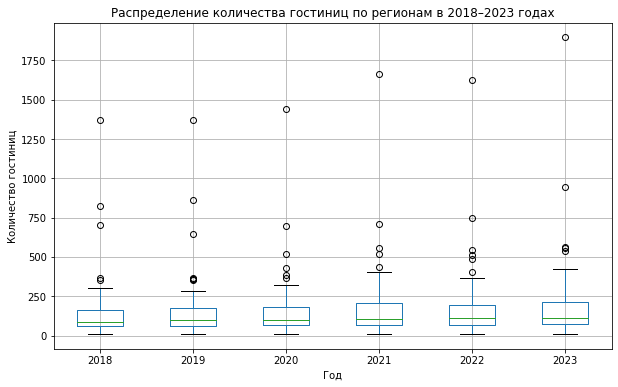

In [22]:
# Строим boxplot для гостиниц
plt.figure(figsize=(10, 6))

hotel[hotel_cols].boxplot()

plt.title('Распределение количества гостиниц по регионам в 2018–2023 годах')
plt.xlabel('Год')
plt.ylabel('Количество гостиниц')
plt.xticks(
    ticks=range(1, 7),
    labels=['2018', '2019', '2020', '2021', '2022', '2023']
)
plt.grid(True)
plt.show()

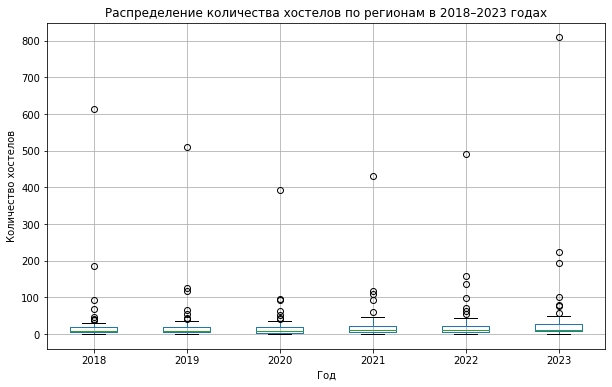

In [23]:
# Строим boxplot для хостелов
plt.figure(figsize=(10, 6))

hotel[hostel_cols].boxplot()

plt.title('Распределение количества хостелов по регионам в 2018–2023 годах')
plt.xlabel('Год')
plt.ylabel('Количество хостелов')
plt.xticks(
    ticks=range(1, 7),
    labels=['2018', '2019', '2020', '2021', '2022', '2023']
)
plt.grid(True)
plt.show()

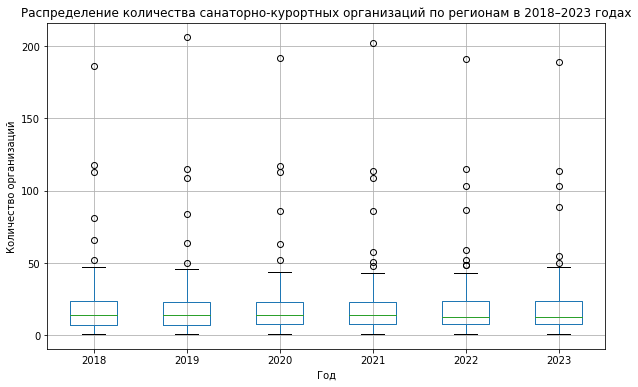

In [24]:
# Строим boxplot для санаторно-курортных организаций
plt.figure(figsize=(10, 6))

hotel[sanatorium_cols].boxplot()

plt.title('Распределение количества санаторно-курортных организаций по регионам в 2018–2023 годах')
plt.xlabel('Год')
plt.ylabel('Количество организаций')
plt.xticks(
    ticks=range(1, 7),
    labels=['2018', '2019', '2020', '2021', '2022', '2023']
)
plt.grid(True)
plt.show()

### Вывод по распределению объектов размещения

Для анализа распределения количества гостиниц, хостелов и санаторно-курортных организаций за 2018–2023 годы были построены диаграммы размаха.

По графику с количеством гостиниц видно, что в большинстве регионов число гостиниц находится на сравнительно невысоком уровне. При этом на протяжении всех лет наблюдаются выраженные выбросы — отдельные регионы имеют значительно больше гостиниц, чем остальные субъекты РФ. Это говорит о неравномерном развитии гостиничной инфраструктуры и концентрации объектов размещения в крупных туристических центрах.

Распределение количества хостелов также неравномерное. В большинстве регионов их немного, но каждый год есть отдельные значения, сильно превышающие общий уровень. Особенно заметен высокий выброс в 2023 году. Это может быть связано с тем, что хостелы чаще сосредоточены в крупных городах и популярных туристических направлениях.

По санаторно-курортным организациям также видна высокая региональная неоднородность. Основная часть регионов имеет небольшое количество таких организаций, но присутствуют субъекты с заметно более высокими значениями. Вероятно, это регионы с развитой санаторно-курортной базой.

В целом можно сделать вывод, что туристическая инфраструктура России распределена по регионам неравномерно. Большинство субъектов имеют относительно небольшое количество гостиниц, хостелов и санаторно-курортных организаций, тогда как отдельные регионы значительно выделяются по числу объектов размещения. Существенного резкого изменения медианных значений за 2018–2023 годы на графиках не наблюдается, однако в 2023 году заметны более высокие максимальные значения по гостиницам и хостелам.


### Топ-10 регионов России с наибольшей стоимостью турпакетов в 2023 году

In [25]:
top_10_tour_cost = (
    tour_cost
    .dropna(subset=['tour_cost_total_2023'])
    .sort_values(by='tour_cost_total_2023', ascending=False)
    .head(10)[['region', 'tour_cost_total_2023']]
)

top_10_tour_cost

,region,tour_cost_total_2023
17,г. Москва,388215.5477
9,Московская область,27151.9902
29,г. Санкт-Петербург,23785.7731
61,Тюменская область,14332.6665
60,Свердловская область,14271.0682
33,Краснодарский край,14250.5485
48,Республика Татарстан,13768.8762
51,Пермский край,12592.6389
53,Нижегородская область,11545.6481
73,Новосибирская область,10433.0335


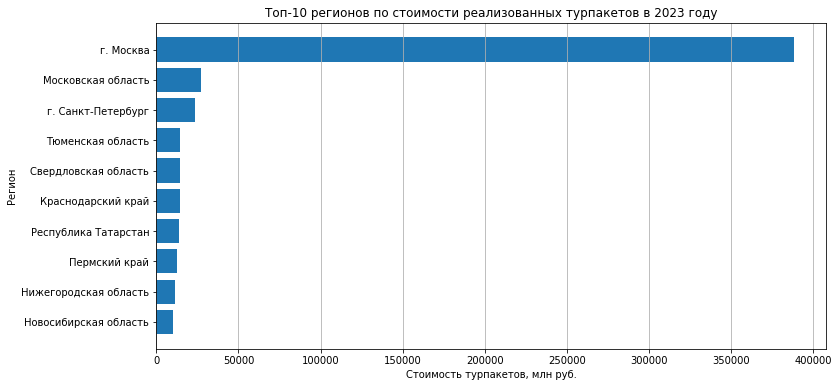

In [26]:
# Построим график

plt.figure(figsize=(12, 6))

plt.barh(
    top_10_tour_cost['region'],
    top_10_tour_cost['tour_cost_total_2023']
)

plt.title('Топ-10 регионов по стоимости реализованных турпакетов в 2023 году')
plt.xlabel('Стоимость турпакетов, млн руб.')
plt.ylabel('Регион')

plt.gca().invert_yaxis()
plt.grid(axis='x')

plt.show()

### Вывод

В топ-10 регионов по стоимости реализованных турпакетов в 2023 году вошли Москва, Московская область, Санкт-Петербург, Тюменская область, Свердловская область, Краснодарский край, Республика Татарстан, Пермский край, Нижегородская область и Новосибирская область.

На графике видно, что Москва значительно опережает остальные регионы по стоимости реализованных турпакетов. Её показатель намного выше, чем у второго региона в рейтинге — Московской области. Это говорит о высокой концентрации продаж турпакетов в столице.

Остальные регионы из топ-10 имеют более близкие между собой значения. В рейтинг вошли как крупные деловые и туристические центры, так и регионы с развитой туристической инфраструктурой.

Таким образом, рынок реализованных турпакетов в 2023 году распределён неравномерно: основная стоимость продаж сосредоточена в Москве, а остальные регионы заметно уступают ей по объёму.

### Изменения среднего количества турпакетов в России по категориям с 2018 по 2023 год

In [27]:
# Создадим списки столбцов по категориям
years = [2018, 2019, 2020, 2021, 2022, 2023]

total_cols = [
    'tour_packages_total_2018',
    'tour_packages_total_2019',
    'tour_packages_total_2020',
    'tour_packages_total_2021',
    'tour_packages_total_2022',
    'tour_packages_total_2023'
]

domestic_cols = [
    'tour_packages_russia_domestic_2018',
    'tour_packages_russia_domestic_2019',
    'tour_packages_russia_domestic_2020',
    'tour_packages_russia_domestic_2021',
    'tour_packages_russia_domestic_2022',
    'tour_packages_russia_domestic_2023'
]

abroad_cols = [
    'tour_packages_russia_abroad_2018',
    'tour_packages_russia_abroad_2019',
    'tour_packages_russia_abroad_2020',
    'tour_packages_russia_abroad_2021',
    'tour_packages_russia_abroad_2022',
    'tour_packages_russia_abroad_2023'
]

foreign_russia_cols = [
    'tour_packages_foreign_russia_2018',
    'tour_packages_foreign_russia_2019',
    'tour_packages_foreign_russia_2020',
    'tour_packages_foreign_russia_2021',
    'tour_packages_foreign_russia_2022',
    'tour_packages_foreign_russia_2023'
]

In [28]:
# Посчитаем среднее количество турпакетов по годам
mean_total = tour_firm[total_cols].mean()
mean_domestic = tour_firm[domestic_cols].mean()
mean_abroad = tour_firm[abroad_cols].mean()
mean_foreign_russia = tour_firm[foreign_russia_cols].mean()

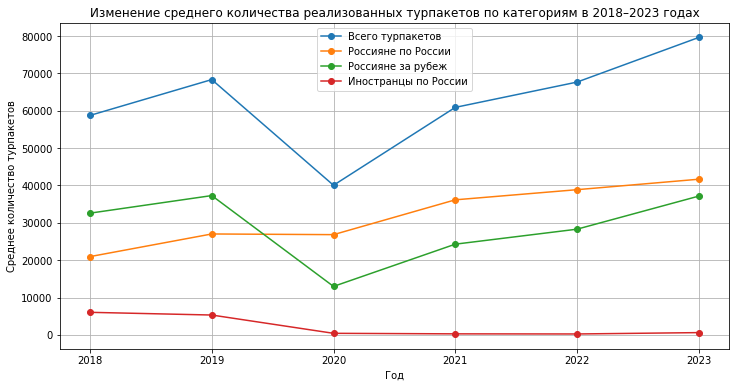

In [29]:
# Построим линейный график

plt.figure(figsize=(12, 6))

plt.plot(years, mean_total, marker='o', label='Всего турпакетов')
plt.plot(years, mean_domestic, marker='o', label='Россияне по России')
plt.plot(years, mean_abroad, marker='o', label='Россияне за рубеж')
plt.plot(years, mean_foreign_russia, marker='o', label='Иностранцы по России')

plt.title('Изменение среднего количества реализованных турпакетов по категориям в 2018–2023 годах')
plt.xlabel('Год')
plt.ylabel('Среднее количество турпакетов')
plt.xticks(years)
plt.grid(True)
plt.legend()

plt.show()

### Вывод

Линейный график показывает динамику среднего количества реализованных турпакетов по регионам России за 2018–2023 годы.

По графику видно, что общее среднее количество турпакетов росло с 2018 по 2019 год, но в 2020 году резко снизилось. Вероятно, это связано с ограничениями в туристической отрасли и снижением туристической активности в период пандемии. После 2020 года показатель начал восстанавливаться и к 2023 году достиг максимального значения за рассматриваемый период.

Похожая динамика наблюдается и по турпакетам россиян за рубеж: в 2020 году произошло сильное снижение, после чего категория постепенно восстанавливалась. К 2023 году среднее количество таких турпакетов заметно выросло, но всё ещё остаётся ниже общего количества реализованных турпакетов.

Турпакеты россиян по России показывают более устойчивую положительную динамику. После 2020 года среднее количество таких турпакетов росло каждый год. Это может говорить о росте интереса к внутреннему туризму.

Категория турпакетов иностранных граждан по России имеет самые низкие значения среди всех категорий. После заметного снижения в 2020 году показатель остаётся на низком уровне, что может указывать на слабое восстановление въездного туризма.

В целом можно сделать вывод, что туристический рынок после спада в 2020 году постепенно восстановился. Основной вклад в рост после 2020 года внесли турпакеты россиян по России и турпакеты россиян за рубеж, тогда как въездной туризм остаётся значительно менее выраженным.

## Проверка гипотез

**Задача 1**

Некоторые СМИ утверждают, что средняя стоимость реализованных турпакетов в 2023 году составляет 800 млн рублей. Однако аналитики подозревают, что этот показатель может быть больше. Наша задача — провести статистический тест, который поможет определить, можно ли отвергнуть нулевую гипотезу в пользу альтернативной.

**1. Форулируем гипотезы**

H₀: средняя стоимость реализованных турпакетов в 2023 году равна 800 млн рублей.

H₁: средняя стоимость реализованных турпакетов в 2023 году больше 800 млн рублей.

то есть:

H₀: μ = 800

H₁: μ > 800

Это односторонний t-тест для среднего значения одной выборки.

**2. Подготовим данные**

In [31]:
# Убраем пропуски, потому что статистический тест не работает с NaN.
tour_cost_sample = tour_cost['tour_cost_total_2023'].dropna()

In [33]:
# Проверим среднее значение:
tour_cost_sample.mean()

8579.186196470586

**3. Проведём статистический тест**

In [34]:
from scipy import stats

alpha = 0.05

result = stats.ttest_1samp(
    tour_cost_sample,
    popmean=800,
    alternative='greater'
)

print('p-value:', result.pvalue)

if result.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-value: 0.04555478027114014
Отвергаем нулевую гипотезу


### Вывод по проверке гипотезы

Для проверки утверждения СМИ была проведена проверка статистической гипотезы о средней стоимости реализованных турпакетов в 2023 году.

Нулевая гипотеза: средняя стоимость реализованных турпакетов в 2023 году равна 800 млн рублей.

Альтернативная гипотеза: средняя стоимость реализованных турпакетов в 2023 году больше 800 млн рублей.

Для проверки был использован односторонний t-тест для среднего значения одной выборки. Перед проведением теста из данных были исключены пропуски в столбце `tour_cost_total_2023`.

Средняя стоимость реализованных турпакетов по выборке составила 8579.19 млн рублей. Полученное значение `p-value` равно 0.0456. Так как `p-value` меньше уровня значимости 0.05, нулевая гипотеза отвергается.

Следовательно, есть статистические основания считать, что средняя стоимость реализованных турпакетов в 2023 году превышает 800 млн рублей.

**Задача 2**

Статистика говорит, что в 2023 году, по сравнению с 2022, россияне стали чаще ездить по стране и оформлять турпакеты. Стоит проверить, так ли это?

**1. Форулируем гипотезы**

H₀: среднее количество турпакетов россиян по России в 2023 году не больше, чем в 2022 году.

H₁: среднее количество турпакетов россиян по России в 2023 году больше, чем в 2022 году.

то есть:

H₀: μ2023 <= μ2022

H₁: μ2023 > μ2022

Так как мы сравниваем показатели по одним и тем же регионам за два года, лучше использовать парный t-тест.

**2. Подготовим данные**

In [36]:
# Оставим только нужные столбцы и удалим строки с пропусками
domestic_tours = tour_firm[
    ['tour_packages_russia_domestic_2022', 'tour_packages_russia_domestic_2023']
].dropna()

# Посмотрим средние значения
mean_2022 = domestic_tours['tour_packages_russia_domestic_2022'].mean()
mean_2023 = domestic_tours['tour_packages_russia_domestic_2023'].mean()

print('Среднее количество турпакетов в 2022 году:', round(mean_2022, 2))
print('Среднее количество турпакетов в 2023 году:', round(mean_2023, 2))

Среднее количество турпакетов в 2022 году: 38866.33
Среднее количество турпакетов в 2023 году: 42724.28


**3. Проведём статистический тест**

In [37]:
alpha = 0.05

result = stats.ttest_rel(
    domestic_tours['tour_packages_russia_domestic_2023'],
    domestic_tours['tour_packages_russia_domestic_2022'],
    alternative='greater'
)

print('p-value:', result.pvalue)

if result.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-value: 0.096833661702839
Не получилось отвергнуть нулевую гипотезу


### Вывод по проверке гипотезы

Для проверки утверждения о том, что в 2023 году россияне стали чаще оформлять турпакеты по России, были сравнены данные за 2022 и 2023 годы по столбцам `tour_packages_russia_domestic_2022` и `tour_packages_russia_domestic_2023`.

Нулевая гипотеза: среднее количество турпакетов по России в 2023 году не больше, чем в 2022 году.

Альтернативная гипотеза: среднее количество турпакетов по России в 2023 году больше, чем в 2022 году.

Среднее количество турпакетов в 2022 году составило 38 866.33, а в 2023 году — 42 724.28. То есть по среднему значению действительно наблюдается рост.

Для проверки статистической значимости был проведён парный односторонний t-тест, так как сравнивались показатели по одним и тем же регионам за два года. Полученное значение `p-value` равно 0.0968.

Так как `p-value` больше уровня значимости 0.05, нулевую гипотезу отвергнуть не получилось. Это означает, что, несмотря на рост среднего значения, статистически значимых оснований утверждать, что россияне стали чаще оформлять турпакеты по России в 2023 году по сравнению с 2022 годом, недостаточно.

## Общий вывод

В ходе проекта были изучены данные агрегатора отелей и туристических фирм по субъектам Российской Федерации. Анализ был направлен на изучение туристической инфраструктуры, стоимости реализованных турпакетов, динамики туристического спроса и проверку статистических гипотез.

На этапе предобработки были загружены и изучены четыре датасета: `hotel`, `count`, `tour_firm` и `tour_cost`. В данных были обнаружены специальные значения `…1`, которые были интерпретированы как скрытые или не опубликованные статистические данные и заменены на `NaN`. Названия столбцов были приведены к более удобному формату: короткие названия на английском языке, нижний регистр и разделение слов через нижнее подчёркивание. Числовые столбцы были приведены к корректным типам данных: показатели количества — к целочисленному типу с поддержкой пропусков, а показатели стоимости — к вещественному типу.

На этапе исследовательского анализа было изучено распределение количества гостиниц, хостелов и санаторно-курортных организаций за 2018–2023 годы. Диаграммы размаха показали, что туристическая инфраструктура распределена по регионам России неравномерно. В большинстве субъектов количество объектов размещения находится на сравнительно невысоком уровне, но отдельные регионы имеют значительно более высокие показатели. Это говорит о концентрации гостиниц, хостелов и санаторно-курортных организаций в крупных туристических и деловых центрах.

Также был определён топ-10 регионов по стоимости реализованных турпакетов в 2023 году. Лидером стала Москва, причём её показатель значительно превышает значения остальных регионов. В топ также вошли Московская область, Санкт-Петербург, Тюменская область, Свердловская область, Краснодарский край, Республика Татарстан, Пермский край, Нижегородская область и Новосибирская область. Это подтверждает, что рынок реализованных турпакетов сильно сконцентрирован в ограниченном числе регионов.

Динамика среднего количества реализованных турпакетов по категориям за 2018–2023 годы показала заметное снижение туристической активности в 2020 году. После этого рынок начал постепенно восстанавливаться. Особенно заметен рост по турпакетам россиян по России, что может говорить о повышении интереса к внутреннему туризму. При этом категория турпакетов иностранных граждан по России остаётся значительно ниже остальных, что указывает на более слабое восстановление въездного туризма.

В рамках проверки первой гипотезы был проведён односторонний t-тест для средней стоимости реализованных турпакетов в 2023 году. Среднее значение по выборке составило 8579.19 млн рублей, а `p-value` оказалось равным 0.0456. Так как значение `p-value` меньше уровня значимости 0.05, нулевая гипотеза была отвергнута. Это означает, что есть статистические основания считать, что средняя стоимость реализованных турпакетов в 2023 году превышает 800 млн рублей. Однако при интерпретации результата важно учитывать влияние сильного выброса — Москвы, где стоимость турпакетов значительно выше, чем в остальных регионах.

В рамках второй гипотезы было проверено, стали ли россияне в 2023 году чаще оформлять турпакеты по России по сравнению с 2022 годом. Среднее количество таких турпакетов выросло с 38 866.33 в 2022 году до 42 724.28 в 2023 году. Однако значение `p-value` составило 0.0968, что выше уровня значимости 0.05. Поэтому нулевую гипотезу отвергнуть не удалось. Несмотря на наблюдаемый рост среднего значения, статистически значимых оснований утверждать, что россияне стали чаще оформлять турпакеты по России в 2023 году, недостаточно.

Таким образом, анализ показал, что туристическая отрасль России после спада в 2020 году постепенно восстанавливается, а внутренний туризм занимает важное место в структуре спроса. При этом рынок остаётся сильно неравномерным: ключевые показатели сосредоточены в небольшом числе регионов, прежде всего в Москве и крупных туристических центрах. Полученные результаты могут быть полезны агрегатору отелей для разработки персонализированных маршрутов, региональных рекомендаций и более точных маркетинговых стратегий.
